In [2]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
api_key = os.getenv("OPENROUTER_API_KEY")

In [22]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="openai/gpt-oss-120b:free",  
    base_url="https://openrouter.ai/api/v1",
    api_key=api_key
)

In [23]:
llm.model

'openai/gpt-oss-120b:free'

In [24]:
## Node Functionality
def chatbot(state:State):
    return  {"messages":[llm.invoke(state['messages'])]}

In [25]:
graph_builder = StateGraph(State)

#adding node
graph_builder.add_node('llmchatbot', chatbot)
#adding edges
graph_builder.add_edge(START, 'llmchatbot')
graph_builder.add_edge("llmchatbot",END)

#compile the graph
graph=graph_builder.compile()

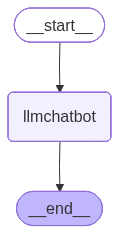

In [26]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [27]:
response=graph.invoke({"messages":"Hi"})

In [28]:
response["messages"][-1].content

'Hello! How can I assist you today?'

In [29]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm doing great, thank you for asking. How can I help you today?


In [ ]:
import os

TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
os.environ[TAVILY_API_KEY] 

from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

print(tool.invoke("what is langgraph"))

{'query': 'what is langgraph', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph', 'title': 'What is LangGraph - GeeksforGeeks', 'content': "LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. LangChain uses a straightforward step-by-step pipeline where each task follows a fixed sequence from input to output while LangGraph allows flexible workflows with branching and parallel steps, making it better suited for complex, decision-based applications. ## Workflow of LangGraph. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. Here's a step by step interpretation of the flow:. In this example we’ll learn how to create a b

ValidationError: 1 validation error for TavilySearchAPIWrapper
  Value error, Did not find tavily_api_key, please add an environment variable `TAVILY_API_KEY` which contains it, or pass `tavily_api_key` as a named parameter. [type=value_error, input_value={}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error